# Task 1: Data Preprocessing

**Index:**

1. Load and Inspect Data
2. Handle Missing Values
3. Feature Type Classification
4. Exploratory Data Analysis (EDA)
5. Feature Encoding & Domain Features
6. Train/Val/Test Split and Target Encoding
7. Feature Standardization
8. Feature Selection and Output

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import data fetcher — auto-downloads dataset if not present
from src.fetch_data import download_dataset

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

## 1. Load and Inspect Data

In [2]:
from src.preprocessing import load_data

# Download raw data (skipped if already present)
data_dir = os.path.join(project_root, "data")
download_dataset(data_dir=data_dir)

# Load raw data
X, y = load_data(data_dir=data_dir)

Data files already exist.
Loaded 4424 samples, 36 features
Target classes: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794


In [3]:
print("Feature Data Types:")
print(X.dtypes.value_counts())
print(f"\nTotal features: {X.shape[1]}")
print(f"Total samples: {X.shape[0]}")

# Get Target Distribution

# Map numeric labels to class names
target_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
y_named = y.map(target_names)

# Calculate class distribution
class_counts = y_named.value_counts()
print("\nClass Distribution:")
print(class_counts)



Feature Data Types:
int64      29
float64     7
Name: count, dtype: int64

Total features: 36
Total samples: 4424

Class Distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [4]:
print("Basic Statistics:")
X.iloc[:, :10].describe().T

Basic Statistics:


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,1.178571,0.605747,1.0,1.0,1.0,1.0,6.0
Application mode,4424.0,18.669078,17.484682,1.0,1.0,17.0,39.0,57.0
Application order,4424.0,1.727848,1.313793,0.0,1.0,1.0,2.0,9.0
Course,4424.0,8856.642631,2063.566416,33.0,9085.0,9238.0,9556.0,9991.0
Daytime/evening attendance,4424.0,0.890823,0.311897,0.0,1.0,1.0,1.0,1.0
Previous qualification,4424.0,4.577758,10.216592,1.0,1.0,1.0,1.0,43.0
Previous qualification (grade),4424.0,132.613314,13.188332,95.0,125.0,133.1,140.0,190.0
Nacionality,4424.0,1.873192,6.914514,1.0,1.0,1.0,1.0,109.0
Mother's qualification,4424.0,19.561935,15.603186,1.0,2.0,19.0,37.0,44.0
Father's qualification,4424.0,22.275316,15.343108,1.0,3.0,19.0,37.0,44.0


## 2. Handle Missing Values

In [5]:
missing = X.isnull().sum()
missing_cols = missing[missing > 0]

info = {
	"total_missing": int(missing.sum()),
	"missing_per_column": missing_cols.to_dict(),
}
print(f"\nMissing info: {info}")


Missing info: {'total_missing': 0, 'missing_per_column': {}}


> **Insight**: As announced in the dataset description, no missing values were detected in the dataset. This is a complete dataset.

## 3. Feature Type Classification

Features are classified into four groups based on their semantics:

- **Nominal**: Unordered categories (e.g., marital status, course)
- **Binary**: 0/1 indicator variables (e.g., gender, scholarship)
- **Ordinal**: Integer values with a meaningful order (e.g., education level, satisfaction rating)
- **Continuous**: Floating-point values (e.g., admission grade, GDP)

In [6]:
from src.preprocessing import get_feature_types

# Get feature type classification
feature_types = get_feature_types(X)

print(f"Nominal features ({len(feature_types['nominal'])}):")
for f in feature_types["nominal"]:
    print(f"  - {f} (unique: {X[f].nunique()})")

print(f"\nBinary features ({len(feature_types['binary'])}):")
for f in feature_types["binary"]:
    print(f"  - {f}")

print(f"\nOrdinal features ({len(feature_types['ordinal'])}):")
for f in feature_types["ordinal"]:
    print(f"  - {f}")

print(f"\nContinuous features ({len(feature_types['continuous'])}):")
for f in feature_types["continuous"]:
    print(f"  - {f}")

Nominal features (8):
  - Marital Status (unique: 6)
  - Application mode (unique: 18)
  - Course (unique: 17)
  - Nacionality (unique: 21)
  - Mother's qualification (unique: 29)
  - Father's qualification (unique: 34)
  - Mother's occupation (unique: 32)
  - Father's occupation (unique: 46)

Binary features (8):
  - Daytime/evening attendance
  - Displaced
  - Educational special needs
  - Debtor
  - Tuition fees up to date
  - Gender
  - Scholarship holder
  - International

Ordinal features (13):
  - Age at enrollment
  - Application order
  - Curricular units 1st sem (approved)
  - Curricular units 1st sem (credited)
  - Curricular units 1st sem (enrolled)
  - Curricular units 1st sem (evaluations)
  - Curricular units 1st sem (without evaluations)
  - Curricular units 2nd sem (approved)
  - Curricular units 2nd sem (credited)
  - Curricular units 2nd sem (enrolled)
  - Curricular units 2nd sem (evaluations)
  - Curricular units 2nd sem (without evaluations)
  - Previous qualifica

In [7]:
# For later convenience, split the features as Nominal and Numerical (binary + ordinal + continuous)

nominal_features = feature_types["nominal"]
print(f"\nNominal features ({len(nominal_features)}): {nominal_features}")

numerical_features = feature_types["binary"] + feature_types["ordinal"] + feature_types["continuous"]
print(f"\nNumerical features ({len(numerical_features)}): {numerical_features}")


Nominal features (8): ['Marital Status', 'Application mode', 'Course', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]

Numerical features (28): ['Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International', 'Age at enrollment', 'Application order', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (without evaluations)', 'Previous qualification', 'Previous qualification (grade)', 'Admission grade', 'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)', 'Unemployment rate'

## 4. Exploratory Data Analysis (EDA)

In [8]:
# Nominal features (11): inspect unique values and counts; sort by counts
# What is the distribution? Is there a long tail of categories in any nominal feature? 

# Pretty print top categories for each nominal feature as a two-row table
for col in nominal_features:
    value_counts = X[col].value_counts().sort_values(ascending=False)
    top_n = 16  # Number of top categories to show
    top_values = value_counts.index[:top_n]
    top_counts = value_counts.values[:top_n]
    print(f"\nFeature: {col} (unique: {len(value_counts)})")
    df_table = pd.DataFrame([top_values, top_counts], index=['Value', 'Count'])
    display(df_table)


Feature: Marital Status (unique: 6)


,0,1,2,3,4,5
Value,1,2,4,5,6,3
Count,3919,379,91,25,6,4



Feature: Application mode (unique: 18)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Value,1,17,39,43,44,7,18,42,51,16,53,15,5,10,2,57
Count,1708,872,785,312,213,139,124,77,59,38,35,30,16,10,3,1



Feature: Course (unique: 17)


...

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Value,37,19,1,38,3,34,2,4,12,39,5,11,36,9,40,30
Count,1209,968,904,702,282,112,68,39,38,20,18,10,8,5,5,4



Feature: Mother's occupation (unique: 32)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Value,9,4,5,3,2,7,0,1,6,90,8,191,99,194,141,123
Count,1577,817,530,351,318,272,144,102,91,70,36,26,17,11,8,7



Feature: Father's occupation (unique: 46)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
Value,9,7,5,4,3,8,10,6,2,1,0,90,99,193,144,171
Count,1010,666,516,386,384,318,266,242,197,134,128,65,19,15,8,8


> **Insight**: Many features exhibit skewed distributions and long tails (e.g., `Nacionality`). Target encoding will work well, while one-hot encoding may lead to high dimensionality and sparsity issues.

Correlation of numerical features with Target (sorted by |correlation|, top 15):
Curricular units 2nd sem (approved)               0.624157
Curricular units 2nd sem (grade)                  0.566827
Curricular units 1st sem (approved)               0.529123
Curricular units 1st sem (grade)                  0.485207
Tuition fees up to date                           0.409827
Scholarship holder                                0.297595
Age at enrollment                                -0.243438
Debtor                                           -0.240999
Gender                                           -0.229270
Curricular units 2nd sem (enrolled)               0.175847
Curricular units 1st sem (enrolled)               0.155974
Admission grade                                   0.120889
Displaced                                         0.113986
Previous qualification (grade)                    0.103764
Curricular units 2nd sem (without evaluations)   -0.094028
Name: Target_num, dtype: float64


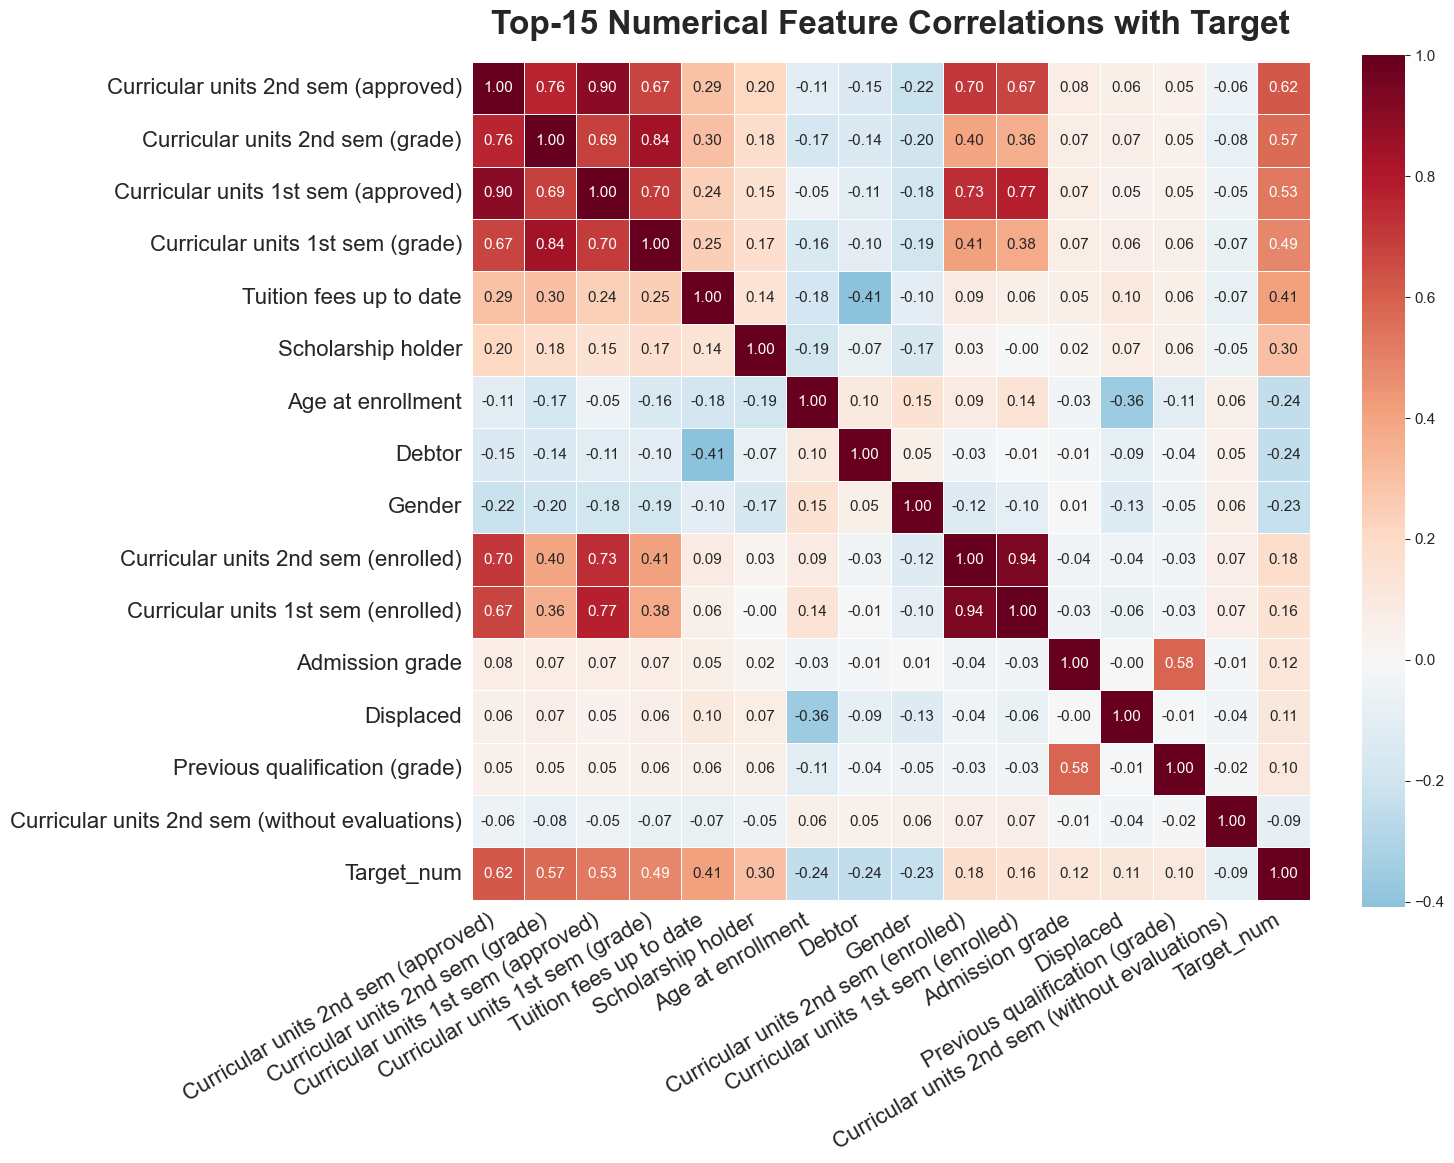

In [9]:
# Numerical features (38): Rank the features by their (absolute) correlation with the target variable. Visualize the top-k features using a correlation heatmap.
k = 15

# Add numeric target column for correlation calculation
combined = X.copy()
combined["Target_num"] = y.values

# Use only numerical features (including binary, ordinal, continuous)
corrs = combined[numerical_features + ["Target_num"]].corr()["Target_num"].drop("Target_num")
# Sort by absolute value, but keep the sign
sorted_corrs = corrs.loc[corrs.abs().sort_values(ascending=False).index]
print(f"Correlation of numerical features with Target (sorted by |correlation|, top {k}):")
print(sorted_corrs.head(k))

# Select top-k features by absolute correlation (with sign)
topk = sorted_corrs.head(k).index.tolist()

# Compute correlation matrix for top-k features + target
corr_matrix = combined[topk + ["Target_num"]].corr()

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5)
plt.title(f"Top-{k} Numerical Feature Correlations with Target", fontsize=24, fontweight="bold", pad=20)
plt.tight_layout()
# Change Label size and rotation
plt.xticks(rotation=30, ha="right", fontsize=16)
plt.yticks(rotation=0, fontsize=16)
plt.savefig(os.path.join(project_root, "data", "plots", "01_eda_correlation_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()

> **Key Observations**:

1. Curricular units between 1st and 2nd, or between grade and admission grade, show strong correlations with each other and with the target variable. These features are likely important predictors of dropout risk.
2. Economic features (e.g., `tuition fees`, `debtor`, `displaced`) show moderate correlations with each other and with the target variable, suggesting that financial factors may also play a role in dropout risk.
3. Other factors such as `age`, `gender`, and `scholarship holder` show weaker but notable correlations with the target variable, indicating that demographic factors may also contribute to dropout risk.

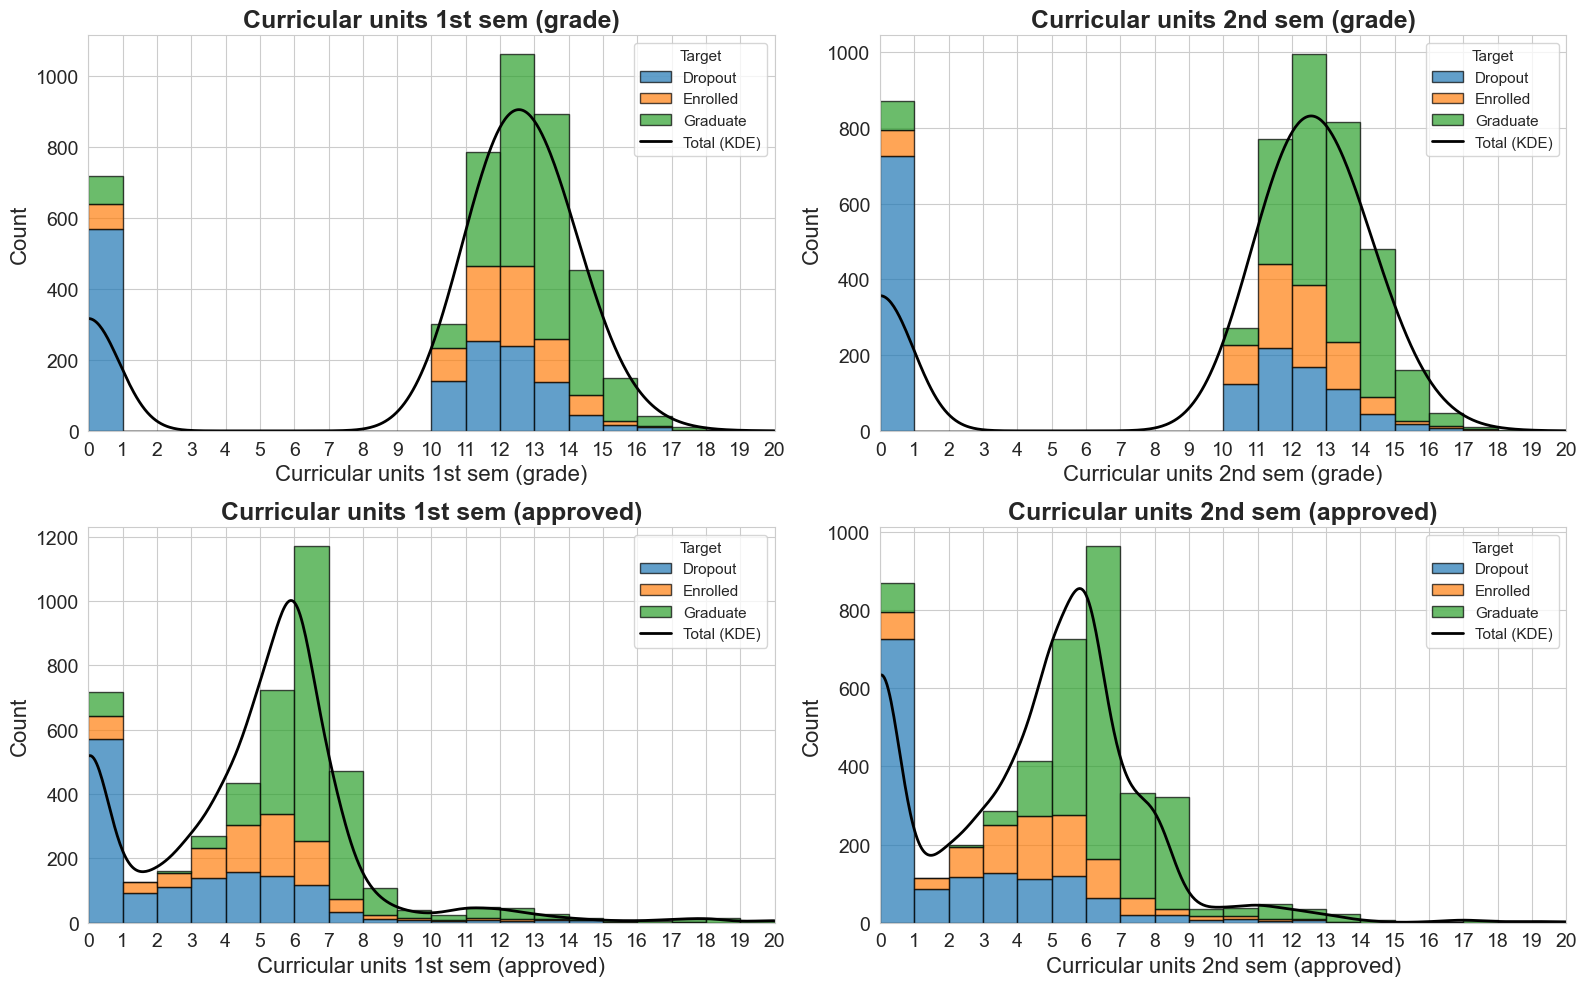

In [10]:
# Inspect the important features in more detail: distributions, outliers, etc. 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

analyzed_features = ["Curricular units 1st sem (grade)", "Curricular units 2nd sem (grade)" , "Curricular units 1st sem (approved)", "Curricular units 2nd sem (approved)"]

for i, col in enumerate(analyzed_features):
	ax = axes[i]
	classes = sorted(y.unique())
	colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
	labels = [target_names[c] for c in classes]
	data = [X[col][y == c] for c in classes]

	# Fix bin range to [0, 20] with width=1
	min_val, max_val = 0, 20
	bin_edges = np.arange(min_val, max_val + 1, 1)

	# Stacked histogram
	counts, bins, _ = ax.hist(
		data, bins=bin_edges, stacked=True, color=colors, label=labels, alpha=0.7, edgecolor='black'
	)

	# KDE trendline (clip data to [0, 20] for KDE)
	all_data = X[col].dropna().clip(min_val, max_val).values
	kde = gaussian_kde(all_data)
	x_grid = np.linspace(min_val, max_val, 500)
	kde_vals = kde(x_grid)
	scale = np.sum([len(d) for d in data]) * 1  # bin width is 1
	ax.plot(x_grid, kde_vals * scale, color='black', linewidth=2, label='Total (KDE)')

	ax.set_xlim(min_val, max_val)
	ax.set_xlabel(col, fontsize=16)
	ax.set_ylabel("Count", fontsize=16)

	ax.set_title(f"{col}", fontsize=18, fontweight="bold")
	ax.tick_params(axis='both', which='major', labelsize=14)

	ax.set_xticks(bin_edges)
	ax.legend(title="Target")

plt.tight_layout()
plt.savefig(os.path.join(project_root, "data", "plots", "01_eda_feature_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()

> **Insight**: The distribution of grades differs significantly across target classes. Graduate students have notably higher 1st and 2nd semester grades compared to Dropout students, with Enrolled students falling in between.

## 5. Feature Encoding & Domain Features

Domain features (academic ratios, financial risk, etc.) are added to the full dataset before encoding.

In [11]:
# Add domain features
from src.feature_engineering import add_all_engineered_features

X_full_eng = add_all_engineered_features(X)
print(f'After domain features: {X_full_eng.shape[1]} features (+ {X_full_eng.shape[1] - X.shape[1]} new)')

After domain features: 61 features (+ 25 new)


## 6. Train/Val/Test Split and Target Encoding

We split the data first, then apply OOF target encoding and standardization only within the training set.
This produces train/val/test sets for use in notebooks 04 and 05.

In [12]:
# Columns to target-encode (high cardinality nominals)
print(f"Nominal features: {nominal_features}")

from sklearn.model_selection import train_test_split
from src.feature_engineering import apply_target_encoding_oof, target_encode_column

# Step 1: split into 85% temp + 15% test first
X_train_val_raw, X_test_raw, y_train_val, y_test = train_test_split(
    X_full_eng, y, test_size=0.15, random_state=42, stratify=y
)
# Step 2: split temp into 70% train + 15% val
val_ratio = 0.15 / 0.85
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_val_raw, y_train_val, test_size=val_ratio, random_state=42, stratify=y_train_val
)
print(f'Split: train={X_train_raw.shape[0]}, val={X_val_raw.shape[0]}, test={X_test_raw.shape[0]}')

# Step 2: OOF target encoding for train (avoids leakage), full mean on val and test
X_train_te, X_test_te = apply_target_encoding_oof(
    X_train_raw, X_test_raw, y_train,
    columns=nominal_features, n_folds=5, smoothing=10.0
)
# Encode val using full training mean
X_val_te = X_val_raw.copy()
for col in nominal_features:
    if col not in X_val_te.columns:
        continue
    _, val_enc = target_encode_column(X_train_raw[col], X_val_raw[col], y_train, smoothing=10.0)
    X_val_te[col] = val_enc.values
print(f'After target encoding: {X_train_te.shape[1]} features')

# Print nominal features samples after encoding
print("\nSample of target-encoded nominal features (train):")
display(X_train_te[nominal_features].head(10))

Nominal features: ['Marital Status', 'Application mode', 'Course', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"]
Split: train=3096, val=664, test=664
After target encoding: 61 features

Sample of target-encoded nominal features (train):


,Marital Status,Application mode,Course,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation
3733,0.910246,0.748996,1.523103,1.180322,1.083858,1.098243,1.228059,1.255071
3977,1.223368,1.264868,1.593456,1.183660,1.078367,1.234751,1.214193,1.036152
4254,1.206808,1.447066,1.172490,1.172518,1.078449,1.130430,1.259726,1.192773
3656,1.215709,1.435154,1.206714,1.174510,1.239543,1.245814,1.242613,1.174280
825,1.223368,1.264868,1.240030,1.183660,1.284483,1.149968,1.236502,1.252692
518,0.966510,0.718206,1.158444,1.174510,0.568749,0.614274,0.664127,0.755818
287,1.215709,0.718206,1.158444,1.174510,0.568749,1.243395,0.572234,0.998095
4146,0.905929,0.748281,1.569838,1.172122,1.074590,1.321936,1.200613,1.241272
1528,1.206808,1.336347,1.038496,1.219763,1.247743,1.211031,1.203007,1.284587
3825,1.215709,1.435154,1.058759,1.174510,1.239543,1.334345,1.220628,1.199768


## 7. Feature Standardization

Continuous and count features are standardized to zero mean and unit variance. 

In [13]:

# Confirm that all features are numerical after encoding and engineering
print(f"Data types after encoding and engineering:\n{X_full_eng.dtypes.value_counts()}")

# Check for nan
print(f"Missing values after encoding and engineering: {X_full_eng.isnull().sum().sum()}")

Data types after encoding and engineering:
int64      33
float64    19
int32       9
Name: count, dtype: int64
Missing values after encoding and engineering: 0


In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def get_scale_columns(df):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude binary columns (all values in {0, 1})
    scale_cols = [col for col in numeric_cols if not set(df[col].dropna().unique()).issubset({0, 1})]
    return scale_cols

# 1. Identify columns to scale using train set only
scale_cols = get_scale_columns(X_train_te)
full_scaler = StandardScaler()
X_scaled = X_full_eng.copy()
X_scaled[scale_cols] = full_scaler.fit_transform(X_full_eng[scale_cols])

# 2. Fit scaler on train
scaler = StandardScaler()
X_train_te_scaled = X_train_te.copy()
X_train_te_scaled[scale_cols] = scaler.fit_transform(X_train_te[scale_cols])

# 3. Transform val and test using the same scaler and columns
X_val_te_scaled = X_val_te.copy()
X_val_te_scaled[scale_cols] = scaler.transform(X_val_te[scale_cols])

X_test_te_scaled = X_test_te.copy()
X_test_te_scaled[scale_cols] = scaler.transform(X_test_te[scale_cols])

In [15]:
# Check that standardization worked correctly by inspecting the summary statistics

print("Standardized Features (sample):")
display(X_scaled.describe().T.round(6).head(10))

# Check that the standardized features have mean ~0 and std ~1
for col in X_scaled.columns:  # show only first 10 for brevity
	mean = X_scaled[col].mean()
	std = X_scaled[col].std()
	if abs(mean) > 1e-3 or abs(std - 1) > 1e-3:
		print(f"Warning: {col} has mean={mean:.6f}, std={std:.6f} (not properly standardized)")

Standardized Features (sample):


,count,mean,std,min,25%,50%,75%,max
Marital Status,4424.0,-0.000000,1.000113,-0.294829,-0.294829,-0.294829,-0.294829,7.960376
Application mode,4424.0,-0.000000,1.000113,-1.010660,-1.010660,-0.095470,1.162916,2.192505
Application order,4424.0,-0.000000,1.000113,-1.315309,-0.554068,-0.554068,0.207173,5.535860
Course,4424.0,0.000000,1.000113,-4.276402,0.110674,0.184826,0.338945,0.549769
Daytime/evening attendance,4424.0,0.890823,0.311897,0.000000,1.000000,1.000000,1.000000,1.000000
Previous qualification,4424.0,-0.000000,1.000113,-0.350230,-0.350230,-0.350230,-0.350230,3.761194
Previous qualification (grade),4424.0,-0.000000,1.000113,-2.852337,-0.577342,0.036907,0.560156,4.351815
Nacionality,4424.0,0.000000,1.000113,-0.126298,-0.126298,-0.126298,-0.126298,15.494786
Mother's qualification,4424.0,-0.000000,1.000113,-1.189759,-1.125662,-0.036018,1.117723,1.566400
Father's qualification,4424.0,0.000000,1.000113,-1.386793,-1.256427,-0.213496,0.959802,1.416085


## 8. Feature Selection and Output

In [16]:
# Use RandomForestClassifier for feature importance ranking (no prediction module dependency)
k=40

from sklearn.ensemble import RandomForestClassifier
from src.feature_engineering import select_features_by_importance

rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(X_train_te, y_train)

# Select top-k features by importance
X_train_top_scaled, top_features = select_features_by_importance(X_train_te_scaled, model=rf_sel, top_k=k)
X_val_top_scaled = X_val_te_scaled[top_features]
X_test_top_scaled = X_test_te_scaled[top_features]

print(f'\nTop features:')
top_imp = pd.Series(rf_sel.feature_importances_, index=X_train_te_scaled.columns).nlargest(20)
print(top_imp.round(4).to_string())

Selected top 40 features out of 61

Top features:
overall_approval_rate                  0.1061
approval_rate_2nd                      0.0738
Curricular units 2nd sem (approved)    0.0593
total_approved                         0.0476
approval_rate_1st                      0.0435
grade_per_evaluation_2nd               0.0407
Curricular units 2nd sem (grade)       0.0326
grade_per_evaluation_1st               0.0304
Course                                 0.0290
Curricular units 1st sem (grade)       0.0255
Admission grade                        0.0234
Curricular units 1st sem (approved)    0.0232
Tuition fees up to date                0.0217
Previous qualification (grade)         0.0212
Mother's occupation                    0.0211
Father's occupation                    0.0201
grade_improvement                      0.0192
Application mode                       0.0186
evaluation_intensity_2nd               0.0185
Age at enrollment                      0.0184


In [17]:
# Save baseline
X_scaled.to_csv(os.path.join(project_root, 'data', 'features_processed.csv'), index=False)
y.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_processed.csv'), index=False)
print(f'Baseline saved: features_processed.csv ({X_scaled.shape[0]} samples, {X_scaled.shape[1]} features)')

# Save engineered train/val/test sets (target encoding + top-40 selection + train-only standardization)
X_train_top_scaled.to_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'), index=False)
y_train.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv'), index=False)
print(f'Train saved: features_engineered_train.csv ({X_train_top_scaled.shape[0]} samples, {X_train_top_scaled.shape[1]} features)')

X_val_top_scaled.to_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'), index=False)
y_val.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv'), index=False)
print(f'Val saved: features_engineered_val.csv ({X_val_top_scaled.shape[0]} samples, {X_val_top_scaled.shape[1]} features)')

X_test_top_scaled.to_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'), index=False)
y_test.to_frame().to_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv'), index=False)
print(f'Test saved: features_engineered_test.csv ({X_test_top_scaled.shape[0]} samples, {X_test_top_scaled.shape[1]} features)')


Baseline saved: features_processed.csv (4424 samples, 61 features)
Train saved: features_engineered_train.csv (3096 samples, 40 features)
Val saved: features_engineered_val.csv (664 samples, 40 features)
Test saved: features_engineered_test.csv (664 samples, 40 features)


<!-- ## 9. Summary & Insights

### Baseline Pipeline (Section 1-7)
- **Domain features**: 20 new features added to full dataset (no target leakage)
- **One-hot encoding**: 8 nominal features encoded
- **Standardization**: Fit on full data
- Output: `features_processed.csv` (4424 samples)

### Engineered Pipeline (Section 8)
1. **Train/Val/Test split first**: 70/15/15 stratified split (before any target-based operations)
2. **OOF target encoding**: Train encoded via 5-fold CV; val/test encoded using full training mean
3. **Standardization**: Fit on train only, transform val and test
4. **Feature selection**: Top-40 by Random Forest importance (fit on train only)
- Output: `features_engineered_train/val/test.csv`

### Key Observations
- Domain features (approval rates, financial risk) are strong predictors
- OOF target encoding avoids target leakage within the training set
- Split-then-encode ensures val and test sets remain truly unseen -->
